In [1]:
import sqlite3
import pandas as pd

In [2]:
conn = sqlite3.connect("sales.db")

In [3]:
q1 = """
SELECT customer_id, name, region
FROM customers
WHERE region = 'Central'
ORDER BY name ASC;
"""

df1 = pd.read_sql_query(q1, conn)
print(df1)

   customer_id        name   region
0            5  Mona Saleh  Central
1            4  Yousef Ali  Central


In [4]:
q2 = """
SELECT o.order_id, c.name AS customer_name, p.name AS product_name,
       o.quantity, p.unit_price, (o.quantity * p.unit_price) AS total_revenue
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
JOIN products p ON o.product_id = p.product_id
ORDER BY total_revenue DESC
LIMIT 5;
"""

df2 = pd.read_sql_query(q2, conn)
print(df2)

   order_id   customer_name product_name  quantity  unit_price  total_revenue
0        18      Yousef Ali     Backpack         5       200.0         1000.0
1        37  Sara Al-Otaibi     Backpack         5       200.0         1000.0
2         3   Aisha Mansour   Headphones         6       150.0          900.0
3        49   Khalid Nasser     Backpack         4       200.0          800.0
4         5      Tariq Bakr   Headphones         5       150.0          750.0


In [5]:
q3 = """
SELECT c.region, SUM(o.quantity * p.unit_price) AS total_revenue
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
JOIN products p ON o.product_id = p.product_id
GROUP BY c.region
ORDER BY total_revenue DESC;
"""

df3 = pd.read_sql_query(q3, conn)
print(df3)

     region  total_revenue
0   Central         6095.0
1   Eastern         5395.0
2   Western         2610.0
3  Northern         1395.0


In [6]:
q4 = """
SELECT name, region
FROM customers
WHERE customer_id IN (
    SELECT customer_id
    FROM orders
    WHERE quantity > (SELECT AVG(quantity) FROM orders)
);
"""

df4 = pd.read_sql_query(q4, conn)
print(df4)

conn.close()

             name    region
0  Sara Al-Otaibi   Eastern
1       Omar Khan   Western
2     Lina Hassan   Eastern
3      Yousef Ali   Central
4      Mona Saleh   Central
5   Khalid Nasser  Northern
6   Aisha Mansour   Western
7      Tariq Bakr   Eastern


The Central region generated the highest total revenue (6,095 SAR) whereas the Northern region generated the lowest total revenue (1,395 SAR)

-----------

Does completing the prep course affect students' final exam scores?

Null Hypothesis ( H0 ):  μYes=μNo
"There is no difference in the mean final scores between students who completed the prep course and those who did not"

Alternative Hypothesis ( H1 ):  μYes≠μNo
"There is a significant difference in the mean final scores between students who completed the prep course and those who did not"

α=0.05

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

In [8]:
df_student = pd.read_csv("student_performance.csv")

In [10]:
yes_scores = df_student[df_student["prep_course"] == "Yes"]["final_score"]
no_scores = df_student[df_student["prep_course"] == "No"]["final_score"]

print(f"Mean (Prep Course = Yes): {yes_scores.mean():.2f}")
print(f"Mean (Prep Course = No): {no_scores.mean():.2f}")

Mean (Prep Course = Yes): 87.57
Mean (Prep Course = No): 83.95


/tmp/ipykernel_2597/2940319736.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


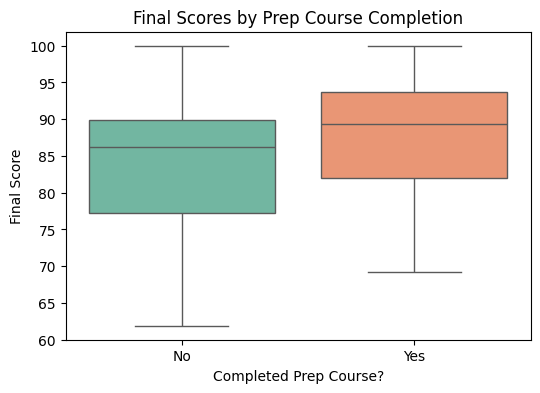

In [11]:
plt.figure(figsize=(6, 4))
sns.boxplot(
    x="prep_course", y="final_score", data=df_student, palette="Set2"
)
plt.title("Final Scores by Prep Course Completion")
plt.xlabel("Completed Prep Course?")
plt.ylabel("Final Score")
plt.show()

In [12]:
res = stats.ttest_ind(yes_scores, no_scores, equal_var=False)
diff = yes_scores.mean() - no_scores.mean()

ci = res.confidence_interval(0.95)

n_yes, n_no = len(yes_scores), len(no_scores)
s_yes, s_no = yes_scores.std(), no_scores.std()
pooled_sd = np.sqrt(
    ((n_yes - 1) * s_yes**2 + (n_no - 1) * s_no**2) / (n_yes + n_no - 2)
)
cohen_d = diff / pooled_sd

print(f"p-value: {res.pvalue:.4f}")
print(f"95% CI: ({ci.low:.2f}, {ci.high:.2f})")
print(f"Cohen's d: {cohen_d:.2f}")

p-value: 0.0375
95% CI: (0.21, 7.02)
Cohen's d: 0.39


The 95% confidence interval for the difference in mean final scores is (0.21, 7.02)

The effect size is Cohen's d = 0.39 indicating a small-to-medium practical effect


Since the p-value ( 0.0375 ) is less than  α=0.05 we reject  H0

 There is a statistically significant difference between the two groups; students who completed the prep course scored significantly higher on average

A limitation is that this is an observational study so we cannot prove cause and effect other factors like study habits or motivation might also affect the scores